<a href="https://colab.research.google.com/github/ketanp23/LLMclass/blob/main/Lab3_Attention_and_Transformers.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Lab 3 · Attention & Transformers

**Course:** Language Models — From N-grams to Transformers
**Goal:** Implement the mechanism behind every modern LLM — **attention** — and assemble it into a **Transformer** block.

You will:
- Implement **scaled dot-product attention** from scratch in NumPy
- **Visualize** attention weights as a heatmap
- Build **multi-head self-attention** in PyTorch
- Add **positional encoding** and stack a full **Transformer encoder block**

> **Runtime tip:** CPU is fine for this lab; everything is small.

## 1 · The core idea

Attention lets every position look at every other position and pull in what's relevant. Each token produces three vectors:

- **Query (Q)** — what am I looking for?
- **Key (K)** — what do I offer?
- **Value (V)** — the content I contribute.

The output for a token is a weighted sum of all Values, where the weights come from how well its Query matches each Key:

$$\text{Attention}(Q,K,V) = \text{softmax}\!\left(\frac{QK^\top}{\sqrt{d_k}}\right)V$$

The $\sqrt{d_k}$ scaling keeps the dot products from getting too large (which would make softmax saturate).

In [1]:
import numpy as np
np.random.seed(0)

def softmax(x, axis=-1):
    x = x - x.max(axis=axis, keepdims=True)
    e = np.exp(x)
    return e / e.sum(axis=axis, keepdims=True)

def scaled_dot_product_attention(Q, K, V, mask=None):
    d_k = Q.shape[-1]
    scores = Q @ K.T / np.sqrt(d_k)          # (seq, seq) similarity
    if mask is not None:
        scores = np.where(mask, scores, -1e9)  # block forbidden positions
    weights = softmax(scores, axis=-1)        # attention weights
    output = weights @ V                       # weighted sum of values
    return output, weights

# Toy example: 4 tokens, 8-dim vectors
seq, d = 4, 8
Q = np.random.randn(seq, d)
K = np.random.randn(seq, d)
V = np.random.randn(seq, d)

out, weights = scaled_dot_product_attention(Q, K, V)
print("output shape :", out.shape)          # (4, 8)
print("weights shape:", weights.shape)      # (4, 4)
print("each row of weights sums to 1 ->", weights.sum(axis=1).round(3))

output shape : (4, 8)
weights shape: (4, 4)
each row of weights sums to 1 -> [1. 1. 1. 1.]


## 2 · Visualize attention on a real sentence

Let's give a sentence toy embeddings and see which words attend to which. The heatmap cell shows the attention matrix — **row = the word doing the looking, column = the word being looked at**.

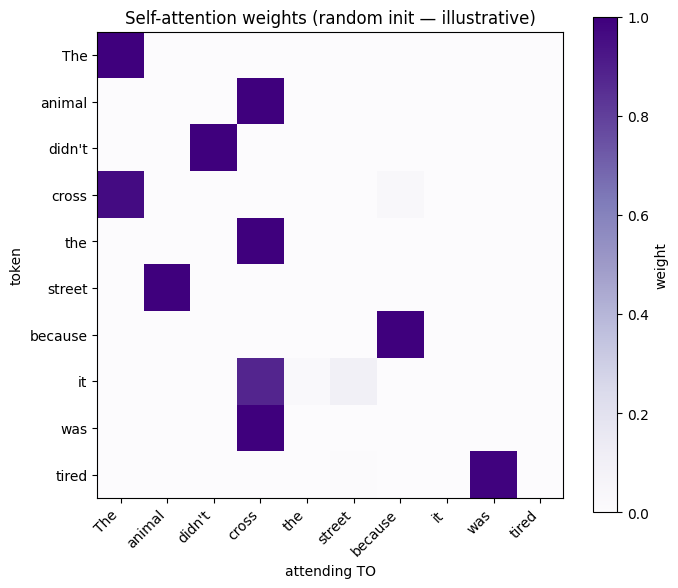

In a *trained* model, the row for 'it' would concentrate weight on 'animal',
resolving the reference regardless of the distance between them.


In [2]:
import matplotlib.pyplot as plt

sentence = ["The", "animal", "didn't", "cross", "the", "street",
            "because", "it", "was", "tired"]
n = len(sentence)
d = 16

# Random projections stand in for learned Q/K/V weights
emb = np.random.randn(n, d)
Wq, Wk, Wv = (np.random.randn(d, d) for _ in range(3))
Q, K, V = emb @ Wq, emb @ Wk, emb @ Wv

_, attn = scaled_dot_product_attention(Q, K, V)

plt.figure(figsize=(7, 6))
plt.imshow(attn, cmap="Purples")
plt.xticks(range(n), sentence, rotation=45, ha="right")
plt.yticks(range(n), sentence)
plt.xlabel("attending TO"); plt.ylabel("token")
plt.title("Self-attention weights (random init — illustrative)")
plt.colorbar(label="weight")
plt.tight_layout(); plt.show()

print("In a *trained* model, the row for 'it' would concentrate weight on 'animal',")
print("resolving the reference regardless of the distance between them.")

## 3 · Causal masking

In a language model, a token may only attend to itself and **earlier** tokens — it can't peek at the future. We enforce this with a lower-triangular **mask**.

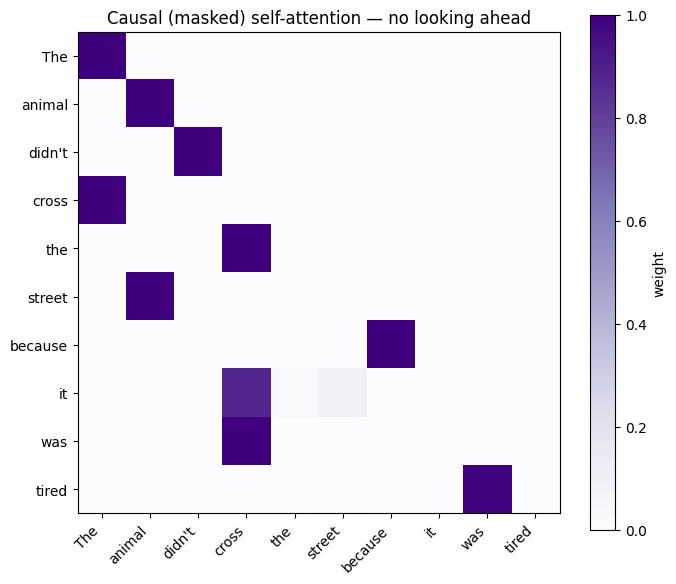

The upper triangle is zero: each token attends only to itself and the past.


In [3]:
causal_mask = np.tril(np.ones((n, n))).astype(bool)  # True = allowed
_, masked_attn = scaled_dot_product_attention(Q, K, V, mask=causal_mask)

plt.figure(figsize=(7, 6))
plt.imshow(masked_attn, cmap="Purples")
plt.xticks(range(n), sentence, rotation=45, ha="right")
plt.yticks(range(n), sentence)
plt.title("Causal (masked) self-attention — no looking ahead")
plt.colorbar(label="weight")
plt.tight_layout(); plt.show()

print("The upper triangle is zero: each token attends only to itself and the past.")

## 4 · Multi-head attention in PyTorch

One attention "head" learns one kind of relationship. **Multi-head attention** runs several in parallel and concatenates them, so the model can capture syntax, coreference, position, and more — all at once.

In [4]:
import torch
import torch.nn as nn
import torch.nn.functional as F

class MultiHeadSelfAttention(nn.Module):
    def __init__(self, d_model, n_heads):
        super().__init__()
        assert d_model % n_heads == 0
        self.n_heads = n_heads
        self.d_head = d_model // n_heads
        self.qkv = nn.Linear(d_model, 3 * d_model)
        self.proj = nn.Linear(d_model, d_model)

    def forward(self, x, causal=False):
        B, T, C = x.shape
        qkv = self.qkv(x).reshape(B, T, 3, self.n_heads, self.d_head)
        q, k, v = qkv.permute(2, 0, 3, 1, 4)     # each (B, heads, T, d_head)
        scores = (q @ k.transpose(-2, -1)) / self.d_head ** 0.5
        if causal:
            mask = torch.tril(torch.ones(T, T, device=x.device)).bool()
            scores = scores.masked_fill(~mask, float("-inf"))
        attn = F.softmax(scores, dim=-1)
        out = attn @ v                            # (B, heads, T, d_head)
        out = out.transpose(1, 2).reshape(B, T, C)
        return self.proj(out), attn

mha = MultiHeadSelfAttention(d_model=32, n_heads=4)
x = torch.randn(1, n, 32)                          # (batch, seq, d_model)
out, attn = mha(x)
print("input :", x.shape)
print("output:", out.shape)
print("attention weights (per head):", attn.shape)   # (B, heads, T, T)

input : torch.Size([1, 10, 32])
output: torch.Size([1, 10, 32])
attention weights (per head): torch.Size([1, 4, 10, 10])


## 5 · Positional encoding

Attention alone is **order-blind** — shuffle the inputs and the output just shuffles too. Transformers inject word order by *adding* a positional signal to each embedding. The original paper uses fixed sine/cosine waves of different frequencies.

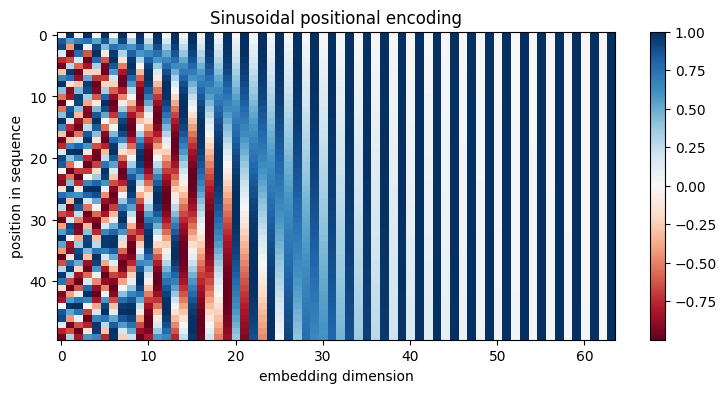

Each position gets a unique, smoothly varying signature the model can read.


In [5]:
def positional_encoding(seq_len, d_model):
    pos = np.arange(seq_len)[:, None]
    i = np.arange(d_model)[None, :]
    angle = pos / np.power(10000, (2 * (i // 2)) / d_model)
    pe = np.zeros((seq_len, d_model))
    pe[:, 0::2] = np.sin(angle[:, 0::2])
    pe[:, 1::2] = np.cos(angle[:, 1::2])
    return pe

pe = positional_encoding(seq_len=50, d_model=64)
plt.figure(figsize=(9, 4))
plt.imshow(pe, cmap="RdBu", aspect="auto")
plt.xlabel("embedding dimension"); plt.ylabel("position in sequence")
plt.title("Sinusoidal positional encoding")
plt.colorbar(); plt.show()
print("Each position gets a unique, smoothly varying signature the model can read.")

## 6 · A full Transformer encoder block

Now we assemble the canonical block:

```
x → Multi-Head Self-Attention → Add & Norm → Feed-Forward → Add & Norm → out
```

The **residual (Add)** connections and **LayerNorm** keep deep stacks stable and trainable; the **feed-forward** network transforms each position independently.

In [6]:
class TransformerBlock(nn.Module):
    def __init__(self, d_model, n_heads, ff_mult=4, dropout=0.1):
        super().__init__()
        self.attn = MultiHeadSelfAttention(d_model, n_heads)
        self.norm1 = nn.LayerNorm(d_model)
        self.norm2 = nn.LayerNorm(d_model)
        self.ff = nn.Sequential(
            nn.Linear(d_model, ff_mult * d_model),
            nn.GELU(),
            nn.Linear(ff_mult * d_model, d_model),
        )
        self.drop = nn.Dropout(dropout)

    def forward(self, x, causal=False):
        # Pre-norm residual connections (as in modern GPT-style models)
        attn_out, attn_w = self.attn(self.norm1(x), causal=causal)
        x = x + self.drop(attn_out)
        x = x + self.drop(self.ff(self.norm2(x)))
        return x, attn_w

block = TransformerBlock(d_model=32, n_heads=4)
x = torch.randn(2, n, 32)
out, attn_w = block(x, causal=True)
print("Transformer block output:", out.shape)
print("Parameters in one block :", sum(p.numel() for p in block.parameters()), "\n")

# Stack a few blocks -> a mini Transformer encoder
encoder = nn.ModuleList([TransformerBlock(32, 4) for _ in range(3)])
h = torch.randn(1, n, 32)
for blk in encoder:
    h, _ = blk(h, causal=True)
print("After 3 stacked blocks:", h.shape)
print("This is, in miniature, the architecture behind BERT and GPT.")

Transformer block output: torch.Size([2, 10, 32])
Parameters in one block : 12704 

After 3 stacked blocks: torch.Size([1, 10, 32])
This is, in miniature, the architecture behind BERT and GPT.


## 7 · Why this replaced RNNs

| | RNN / LSTM | Transformer |
|---|---|---|
| Processing | sequential, step by step | **parallel**, all positions at once |
| Long-range context | fades with distance | **direct** — any position attends to any other |
| Training speed | slow on GPUs | **highly efficient** |
| Scalability | limited | scales to **billions** of parameters |

Same building block, stacked and scaled, powers today's large language models.

## 8 · Your turn 🧪

1. **Heads matter:** change `n_heads` to 1 and to 8 in the multi-head module. Inspect `attn.shape`.
2. **Masking:** re-run the encoder with `causal=False` and confirm tokens can now attend to the future.
3. **Depth:** stack 6 blocks instead of 3 and count the total parameters.
4. **Positional variants:** replace sinusoidal encoding with a learned `nn.Embedding(seq_len, d_model)`. Which is used in GPT?
5. **Stretch:** wire an embedding layer + positional encoding + the encoder stack + a linear head into a tiny character LM and train it on the Lab 2 text. Compare its samples to the LSTM's.

In [7]:
# Scratch space for your experiments
